# Lesson 17A: Spectral Clustering — Theory

## Introduction

Every clustering algorithm so far has asked a question about *distance*. K-Means (Lesson 1) asks which points are close to a common centre. GMM (Lesson 4) asks which points are likely under a common Gaussian. Both assume a cluster is a **blob**: compact, roughly convex, well described by a centre.

Some structure is not blob-shaped. Two interlocking crescents, or a ring inside a ring, have an obvious answer that a human sees instantly — and K-Means gets it wrong every time, because the points at the two tips of one crescent are further apart than points on facing edges of *different* crescents. No choice of centres can fix that. The problem is not the optimiser; it is the question.

Spectral clustering asks a different question: **which points are connected?** Build a graph where each point is a node and edges join near neighbours, and the crescents become two components joined by almost nothing. Cutting a graph into weakly-connected pieces is a combinatorial problem, and a hard one — but its *relaxation* has a closed-form answer given by the eigenvectors of a matrix called the graph Laplacian. That is the whole idea: **turn a graph-partitioning problem into an eigenvalue problem, solve it in closed form, and cluster the result with K-Means.**

The reason this lesson exists is that the derivation is genuinely instructive. The Laplacian's eigenvalues literally count the connected components of the graph; its smallest non-trivial eigenvector is the best "soft" bipartition; and the algorithm everyone writes down is a relaxation whose tightness we can measure numerically rather than take on faith.

In this lesson:
1. Build the three standard similarity graphs and see how the choice changes connectivity
2. Define the three Laplacians and *prove* their properties numerically, including the component-counting theorem
3. Derive RatioCut and NCut, relax them, and check the relaxation against brute-force optimal cuts on a small graph
4. Use the eigengap to choose K
5. Implement `spectral_clustering()` from scratch in NumPy and validate it against scikit-learn
6. Break it deliberately — bad bandwidth, disconnected graphs — so the failure modes are recognisable

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [Where Distance-Based Clustering Fails](#motivation)
4. [Similarity Graphs](#similarity-graphs)
5. [Graph Laplacians and Their Properties](#laplacians)
6. [Why the Eigenvectors: RatioCut, NCut and the Relaxation](#relaxation)
7. [Choosing K: the Eigengap Heuristic](#eigengap)
8. [Spectral Clustering From Scratch](#from-scratch)
9. [Failure Modes](#failure-modes)
10. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.spatial.distance import cdist
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Libraries loaded.")

Libraries loaded.


<a name="motivation"></a>
## Where Distance-Based Clustering Fails

Two datasets that every clustering library ships with, and that K-Means cannot solve at any K: two interlocking moons, and two concentric circles. Look at what K-Means does and, more importantly, *why* — the decision boundary between two K-Means clusters is always a straight line (the perpendicular bisector of the two centres), so any cluster it produces is convex. A crescent is not convex.

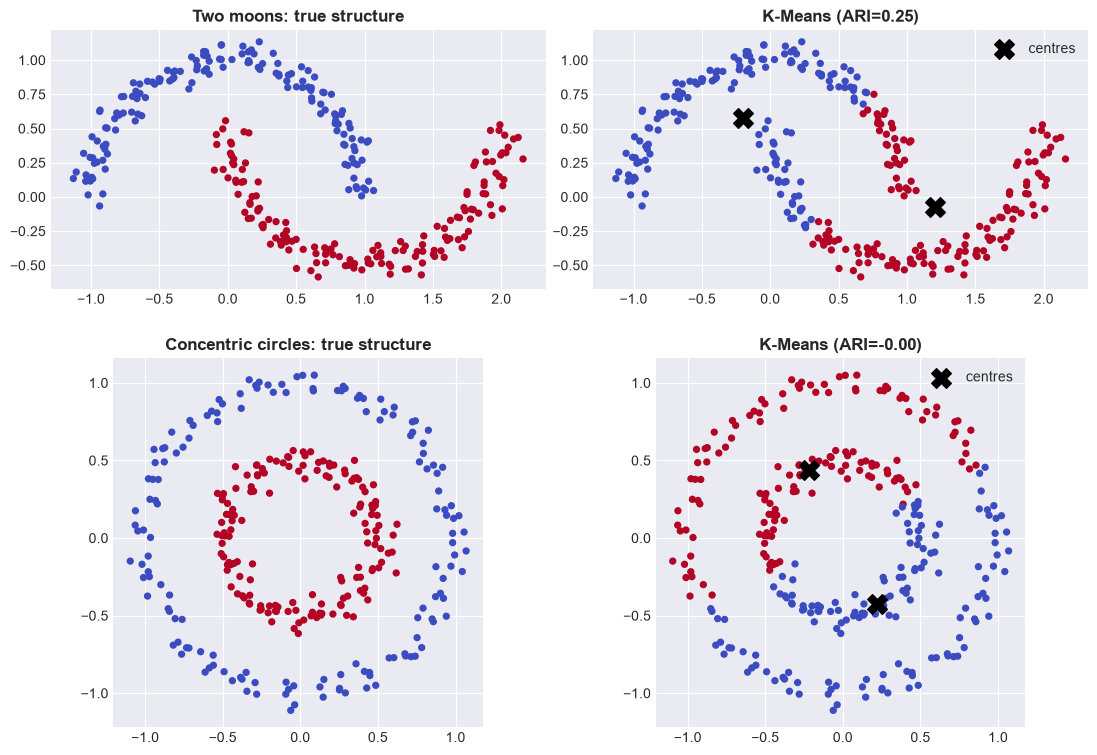

K-Means splits each dataset with a straight line, because the perpendicular bisector of two
centres IS a straight line. Its clusters are convex by construction; these clusters are not.


In [2]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.06, random_state=42)
X_circles, y_circles = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for row, (X, y, name) in enumerate([(X_moons, y_moons, 'Two moons'),
                                    (X_circles, y_circles, 'Concentric circles')]):
    km = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X)
    axes[row, 0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=18)
    axes[row, 0].set_title(f'{name}: true structure', fontweight='bold')
    axes[row, 1].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='coolwarm', s=18)
    axes[row, 1].scatter(*km.cluster_centers_.T, c='black', marker='X', s=200, label='centres')
    axes[row, 1].set_title(f'K-Means (ARI={adjusted_rand_score(y, km.labels_):.2f})', fontweight='bold')
    axes[row, 1].legend()
    for ax in axes[row]:
        ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print("K-Means splits each dataset with a straight line, because the perpendicular bisector of two")
print("centres IS a straight line. Its clusters are convex by construction; these clusters are not.")

<a name="similarity-graphs"></a>
## Similarity Graphs

Reframe the data as a weighted graph $G = (V, E)$: one node per point, edge weights $w_{ij} \ge 0$ measuring similarity. The **similarity matrix** $W$ is symmetric with $w_{ii} = 0$. Three standard constructions:

**$\varepsilon$-neighbourhood graph.** Connect $i$ and $j$ if $\|x_i - x_j\| \le \varepsilon$, with weight 1. Unweighted, and brutally sensitive to $\varepsilon$: too small disconnects the data into dust, too large connects everything.

**$k$-nearest-neighbour graph.** Connect $i$ to its $k$ nearest neighbours. This relation is *not symmetric* — $j$ can be among $i$'s neighbours without $i$ being among $j$'s — so it needs symmetrising, and there are two conventions:
- **kNN graph**: connect if $i \in \mathrm{kNN}(j)$ **or** $j \in \mathrm{kNN}(i)$ (the union; the usual default)
- **mutual kNN graph**: connect only if **both** hold (the intersection; sparser, and tends to leave regions of differing density disconnected — sometimes exactly what you want)

**Fully connected graph with an RBF kernel.** Every pair connected, weight
$$w_{ij} = \exp\!\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right).$$
Nothing is disconnected, but weights decay fast, so $\sigma$ plays the role $\varepsilon$ plays above. This is the construction most tutorials use and the one whose bandwidth we will break later.

The point of the comparison below is that these are not interchangeable: the same data gives different numbers of connected components under each.

construction            edges   components
------------------------------------------
eps = 0.15               1483            2
eps = 0.40               5131            1
kNN k=5 (union)           934            2
mutual kNN k=5            566           15
RBF sigma=0.1            8261            1
RBF sigma=1.0           44850            1


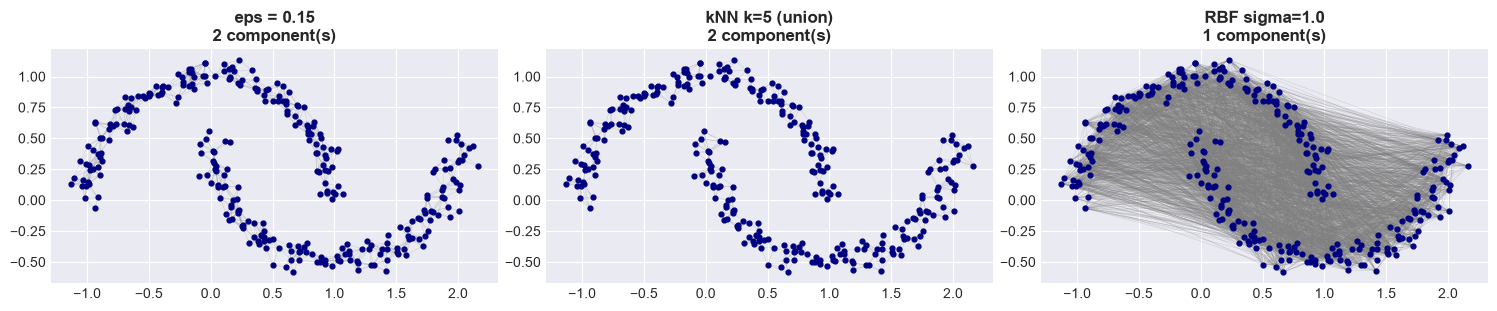

A tight eps shatters the data; a loose RBF connects everything into one component.
kNN sits between: sparse, scale-adaptive, and it keeps the two moons nearly separate.


In [3]:
def rbf_affinity(X, sigma):
    # Fully connected graph, Gaussian weights, zero diagonal.
    sq = cdist(X, X, 'sqeuclidean')
    W = np.exp(-sq / (2 * sigma ** 2))
    np.fill_diagonal(W, 0.0)
    return W


def epsilon_affinity(X, eps):
    # eps-neighbourhood graph: unweighted, symmetric by construction.
    W = (cdist(X, X) <= eps).astype(float)
    np.fill_diagonal(W, 0.0)
    return W


def knn_affinity(X, k, mutual=False):
    # kNN graph. mutual=False takes the union (standard), True the intersection.
    D = cdist(X, X)
    np.fill_diagonal(D, np.inf)
    idx = np.argsort(D, axis=1)[:, :k]
    A = np.zeros_like(D)
    A[np.arange(len(X))[:, None], idx] = 1.0          # A[i, j] = 1 iff j in kNN(i)
    W = np.minimum(A, A.T) if mutual else np.maximum(A, A.T)
    np.fill_diagonal(W, 0.0)
    return W


def n_components(W, tol=1e-8):
    # Connected components by breadth-first search on the adjacency pattern.
    n, seen, comps = len(W), np.zeros(len(W), bool), 0
    for start in range(n):
        if seen[start]:
            continue
        comps += 1
        stack = [start]
        seen[start] = True
        while stack:
            u = stack.pop()
            for v in np.flatnonzero((W[u] > tol) & ~seen):
                seen[v] = True
                stack.append(v)
    return comps


X = X_moons
builds = [('eps = 0.15', epsilon_affinity(X, 0.15)),
          ('eps = 0.40', epsilon_affinity(X, 0.40)),
          ('kNN k=5 (union)', knn_affinity(X, 5)),
          ('mutual kNN k=5', knn_affinity(X, 5, mutual=True)),
          ('RBF sigma=0.1', rbf_affinity(X, 0.1)),
          ('RBF sigma=1.0', rbf_affinity(X, 1.0))]

print(f"{'construction':<20} {'edges':>8} {'components':>12}")
print("-" * 42)
for name, W in builds:
    edges = int((W > 1e-8).sum() // 2)
    print(f"{name:<20} {edges:>8} {n_components(W):>12}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, W) in zip(axes, [builds[0], builds[2], builds[5]]):
    ax.scatter(X[:, 0], X[:, 1], s=12, zorder=3, c='navy')
    ii, jj = np.where(np.triu(W) > 1e-8)
    if len(ii) > 4000:                      # keep the plot readable for dense graphs
        sel = np.random.choice(len(ii), 4000, replace=False)
        ii, jj = ii[sel], jj[sel]
    for a, b in zip(ii, jj):
        ax.plot(X[[a, b], 0], X[[a, b], 1], lw=0.3, alpha=0.35, c='grey', zorder=1)
    ax.set_title(f'{name}\n{n_components(W)} component(s)', fontweight='bold')
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print("A tight eps shatters the data; a loose RBF connects everything into one component.")
print("kNN sits between: sparse, scale-adaptive, and it keeps the two moons nearly separate.")

<a name="laplacians"></a>
## Graph Laplacians and Their Properties

Let $D$ be the diagonal **degree matrix**, $d_i = \sum_j w_{ij}$. Three Laplacians:

$$L = D - W \qquad\text{(unnormalised)}$$
$$L_{\mathrm{sym}} = D^{-1/2} L D^{-1/2} = I - D^{-1/2} W D^{-1/2}$$
$$L_{\mathrm{rw}} = D^{-1} L = I - D^{-1} W$$

**The identity everything rests on.** For any vector $f \in \mathbb{R}^n$:

$$f^\top L f = \frac{1}{2}\sum_{i,j} w_{ij}\,(f_i - f_j)^2 .$$

*Proof sketch:* $f^\top L f = \sum_i d_i f_i^2 - \sum_{ij} w_{ij} f_i f_j$, and since $\sum_{ij} w_{ij}(f_i-f_j)^2 = \sum_{ij}w_{ij}f_i^2 - 2\sum_{ij}w_{ij}f_if_j + \sum_{ij}w_{ij}f_j^2 = 2\sum_i d_i f_i^2 - 2\sum_{ij}w_{ij}f_if_j$, halving gives the result. $\blacksquare$

Three consequences fall straight out, and we check all three numerically below:

1. **$L$ is positive semi-definite.** The right-hand side is a sum of non-negative terms, so $f^\top L f \ge 0$ for every $f$. All eigenvalues are $\ge 0$.
2. **$\mathbf{1}$ is always an eigenvector with eigenvalue 0**, since $L\mathbf{1} = D\mathbf{1} - W\mathbf{1} = 0$.
3. **The multiplicity of eigenvalue 0 equals the number of connected components**, and the corresponding eigenspace is spanned by the indicator vectors of those components. If $f^\top L f = 0$ then $f_i = f_j$ whenever $w_{ij} > 0$, so $f$ is constant on each connected component — and any such $f$ is in the null space.

Property 3 is the bridge from linear algebra to clustering: **the Laplacian's spectrum counts the pieces of the graph.** If the data really consisted of $k$ perfectly separated groups, the $k$ smallest eigenvalues would all be exactly 0 and their eigenvectors would tell us the grouping exactly. Real data is not perfectly separated, so instead we get $k$ *near*-zero eigenvalues — and that "near" is what the whole algorithm exploits.

In [4]:
def laplacians(W):
    # Return (L, L_sym, L_rw) for a symmetric non-negative affinity matrix W.
    d = W.sum(axis=1)
    L = np.diag(d) - W
    d_safe = np.where(d > 0, d, 1.0)                # isolated nodes: avoid 1/0
    d_inv_sqrt = 1.0 / np.sqrt(d_safe)
    L_sym = L * d_inv_sqrt[:, None] * d_inv_sqrt[None, :]
    L_rw = L / d_safe[:, None]
    return L, L_sym, L_rw


# A graph with a KNOWN number of components: three well-separated blobs, tight RBF.
X_blobs, y_blobs = make_blobs(n_samples=150, centers=3, cluster_std=0.35,
                              center_box=(-8, 8), random_state=7)
W_b = rbf_affinity(X_blobs, sigma=0.4)
W_b[W_b < 1e-6] = 0.0                                # threshold: genuinely disconnect the blobs
L, L_sym, L_rw = laplacians(W_b)

f = np.random.randn(len(W_b))
quad_direct = f @ L @ f
quad_identity = 0.5 * np.sum(W_b * (f[:, None] - f[None, :]) ** 2)
print(f"Property 1 — the quadratic-form identity")
print(f"  f^T L f              = {quad_direct:.8f}")
print(f"  (1/2) sum w(fi-fj)^2 = {quad_identity:.8f}")
print(f"  agree: {np.isclose(quad_direct, quad_identity)}   (and both >= 0, so L is PSD)")

evals = np.linalg.eigvalsh(L)
print(f"\n  smallest eigenvalue of L = {evals[0]:.2e}  (never negative up to float error)")

print(f"\nProperty 2 — the constant vector")
ones = np.ones(len(W_b))
print(f"  ||L @ 1|| = {np.linalg.norm(L @ ones):.2e}   (zero: 1 is an eigenvector with eigenvalue 0)")

print(f"\nProperty 3 — zero eigenvalues count components")
k_true = n_components(W_b)
n_zero = int((evals < 1e-8).sum())
print(f"  connected components (BFS)        = {k_true}")
print(f"  eigenvalues of L below 1e-8       = {n_zero}")
print(f"  first six eigenvalues             = {np.round(evals[:6], 6)}")
print(f"  match: {k_true == n_zero}")

print(f"\n  Normalised versions share the property (their zero-eigenvalue counts):")
print(f"    L_sym: {int((np.linalg.eigvalsh(L_sym) < 1e-8).sum())}    "
      f"L_rw: {int((np.abs(np.linalg.eigvals(L_rw)) < 1e-8).sum())}")

Property 1 — the quadratic-form identity
  f^T L f              = 2887.50917759
  (1/2) sum w(fi-fj)^2 = 2887.50917759
  agree: True   (and both >= 0, so L is PSD)

  smallest eigenvalue of L = -1.78e-14  (never negative up to float error)

Property 2 — the constant vector
  ||L @ 1|| = 3.71e-14   (zero: 1 is an eigenvector with eigenvalue 0)

Property 3 — zero eigenvalues count components
  connected components (BFS)        = 3
  eigenvalues of L below 1e-8       = 3
  first six eigenvalues             = [-0.        0.        0.        5.260682  5.791591  6.083645]
  match: True

  Normalised versions share the property (their zero-eigenvalue counts):
    L_sym: 3    L_rw: 3


<a name="relaxation"></a>
## Why the Eigenvectors: RatioCut, NCut and the Relaxation

We want to cut the graph into $k$ pieces with little weight crossing between them. The weight crossing a partition is
$$\mathrm{cut}(A_1,\dots,A_k) = \frac{1}{2}\sum_{i=1}^{k} W(A_i, \bar{A_i}), \qquad W(A,B) = \sum_{i \in A, j \in B} w_{ij}.$$

Minimising this alone is a bad objective: the cheapest cut is usually to lop off a single point. Both standard fixes divide by a measure of set size:

$$\mathrm{RatioCut}(A_1,\dots,A_k) = \sum_{i=1}^k \frac{W(A_i, \bar{A_i})}{|A_i|}, \qquad
\mathrm{NCut}(A_1,\dots,A_k) = \sum_{i=1}^k \frac{W(A_i, \bar{A_i})}{\mathrm{vol}(A_i)}$$

with $\mathrm{vol}(A) = \sum_{i \in A} d_i$. RatioCut balances by **count**, NCut by **volume** (total degree). Both make the objective NP-hard.

**The relaxation, for $k=2$.** Define, for a partition $(A, \bar A)$, the vector
$$f_i = \begin{cases} \sqrt{|\bar A|/|A|} & i \in A \\ -\sqrt{|A|/|\bar A|} & i \in \bar A. \end{cases}$$
Two facts follow by direct computation: $\sum_i f_i = 0$ (so $f \perp \mathbf{1}$), and $\|f\|^2 = n$. Substituting into the quadratic-form identity gives, after algebra,
$$f^\top L f = n \cdot \mathrm{RatioCut}(A, \bar A).$$

So minimising RatioCut over partitions is *exactly* minimising $f^\top L f$ over that discrete set of vectors. The relaxation drops the requirement that $f$ take only two values and allows any real $f$:

$$\min_{f \in \mathbb{R}^n} f^\top L f \quad \text{subject to} \quad f \perp \mathbf{1}, \; \|f\| = \sqrt{n}.$$

By the **Rayleigh–Ritz theorem** the solution is the eigenvector of $L$ for the *second*-smallest eigenvalue (the smallest is 0 with eigenvector $\mathbf{1}$, which the orthogonality constraint excludes). That vector is the **Fiedler vector**, and we recover a partition by thresholding it — usually at zero, or by running K-Means on it.

For general $k$ the same argument with a matrix $H \in \mathbb{R}^{n \times k}$ of indicator columns gives $\min \operatorname{tr}(H^\top L H)$ s.t. $H^\top H = I$, whose relaxed solution is the $k$ smallest eigenvectors. **NCut relaxes the same way but to $L_{\mathrm{rw}}$ / $L_{\mathrm{sym}}$** instead of $L$ — that is the only difference between the two algorithm families.

**How good is the relaxation?** Nobody proves it is tight in general; there are graphs where it is arbitrarily bad. So rather than assert it, the cell below *measures* it: on a graph small enough to enumerate all $2^{n-1}-1$ bipartitions, it compares the true RatioCut optimum against what thresholding the Fiedler vector gives.

Brute force over all 8191 bipartitions of a 14-node graph
  optimal RatioCut            = 0.065541
  Fiedler-vector RatioCut     = 0.065541
  ratio (relaxed / optimal)   = 1.0000
  identical partition?          True

The relaxation's lower bound (Rayleigh quotient at the optimum):
  lambda_2 * n                = 0.860104
  n * optimal RatioCut        = 0.917581
  lambda_2 * n <= n * RatioCut: True  (the relaxed minimum lower-bounds the true one, as it must)


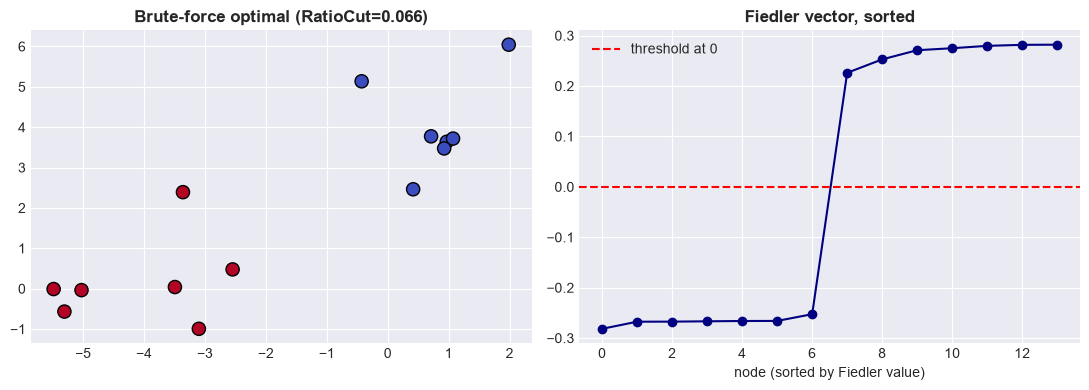

The sorted Fiedler vector shows a visible gap at zero — that gap IS the partition.


In [5]:
def ratio_cut(W, labels):
    # RatioCut for a 2-way partition given as a boolean/0-1 label vector.
    A = labels.astype(bool)
    if A.all() or (~A).all():
        return np.inf                                # degenerate: one side empty
    cut = W[np.ix_(A, ~A)].sum()
    return cut / A.sum() + cut / (~A).sum()


# Small graph so brute force is possible: 14 nodes, two loose groups.
rng = np.random.RandomState(0)
X_small, _ = make_blobs(n_samples=14, centers=2, cluster_std=1.1, random_state=3)
W_s = rbf_affinity(X_small, sigma=1.5)
n = len(W_s)

best_val, best_lab = np.inf, None                     # brute force over all bipartitions
for r in range(1, n // 2 + 1):
    for subset in combinations(range(n), r):
        lab = np.zeros(n, int)
        lab[list(subset)] = 1
        v = ratio_cut(W_s, lab)
        if v < best_val:
            best_val, best_lab = v, lab.copy()

L_s, _, _ = laplacians(W_s)
evals_s, evecs_s = np.linalg.eigh(L_s)
fiedler = evecs_s[:, 1]                               # second-smallest eigenvector
relaxed_lab = (fiedler > 0).astype(int)
relaxed_val = ratio_cut(W_s, relaxed_lab)

print(f"Brute force over all {2 ** (n - 1) - 1} bipartitions of a {n}-node graph")
print(f"  optimal RatioCut            = {best_val:.6f}")
print(f"  Fiedler-vector RatioCut     = {relaxed_val:.6f}")
print(f"  ratio (relaxed / optimal)   = {relaxed_val / best_val:.4f}")
print(f"  identical partition?          {adjusted_rand_score(best_lab, relaxed_lab) == 1.0}")

print(f"\nThe relaxation's lower bound (Rayleigh quotient at the optimum):")
print(f"  lambda_2 * n                = {evals_s[1] * n:.6f}")
print(f"  n * optimal RatioCut        = {n * best_val:.6f}")
print(f"  lambda_2 * n <= n * RatioCut: {evals_s[1] * n <= n * best_val + 1e-9}  "
      f"(the relaxed minimum lower-bounds the true one, as it must)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(X_small[:, 0], X_small[:, 1], c=best_lab, cmap='coolwarm', s=90, edgecolor='k')
axes[0].set_title(f'Brute-force optimal (RatioCut={best_val:.3f})', fontweight='bold')
order = np.argsort(fiedler)
axes[1].plot(fiedler[order], 'o-', color='navy')
axes[1].axhline(0, color='red', ls='--', label='threshold at 0')
axes[1].set_title('Fiedler vector, sorted', fontweight='bold')
axes[1].set_xlabel('node (sorted by Fiedler value)')
axes[1].legend()
plt.tight_layout()
plt.show()

print("The sorted Fiedler vector shows a visible gap at zero — that gap IS the partition.")

<a name="eigengap"></a>
## Choosing K: the Eigengap Heuristic

Property 3 said $k$ perfectly separated components produce exactly $k$ zero eigenvalues. Perturb those components slightly — add a few weak edges between them — and matrix perturbation theory says the $k$ zero eigenvalues lift only slightly, while $\lambda_{k+1}$ stays comparatively large.

That gives the **eigengap heuristic**: choose the $k$ maximising $\lambda_{k+1} - \lambda_k$, or equivalently look at the sorted eigenvalues and find where they visibly jump. It is a heuristic, not a theorem: it is decisive when clusters are well separated and mute when they are not — which is honest, because when clusters overlap badly there *is* no well-defined K.

three tight blobs                eigengap K = 3   (true 3)   first eigenvalues [-0.000e+00  0.000e+00  1.000e-04  6.244e-01  6.371e-01  6.382e-01]
five tight blobs                 eigengap K = 5   (true 5)   first eigenvalues [-0.00e+00 -0.00e+00  0.00e+00  0.00e+00  1.00e-04  6.14e-01]
three blobs, heavy overlap       eigengap K = 2   (true 3)   first eigenvalues [-0.      0.0018  0.0176  0.0224  0.0283  0.0386]


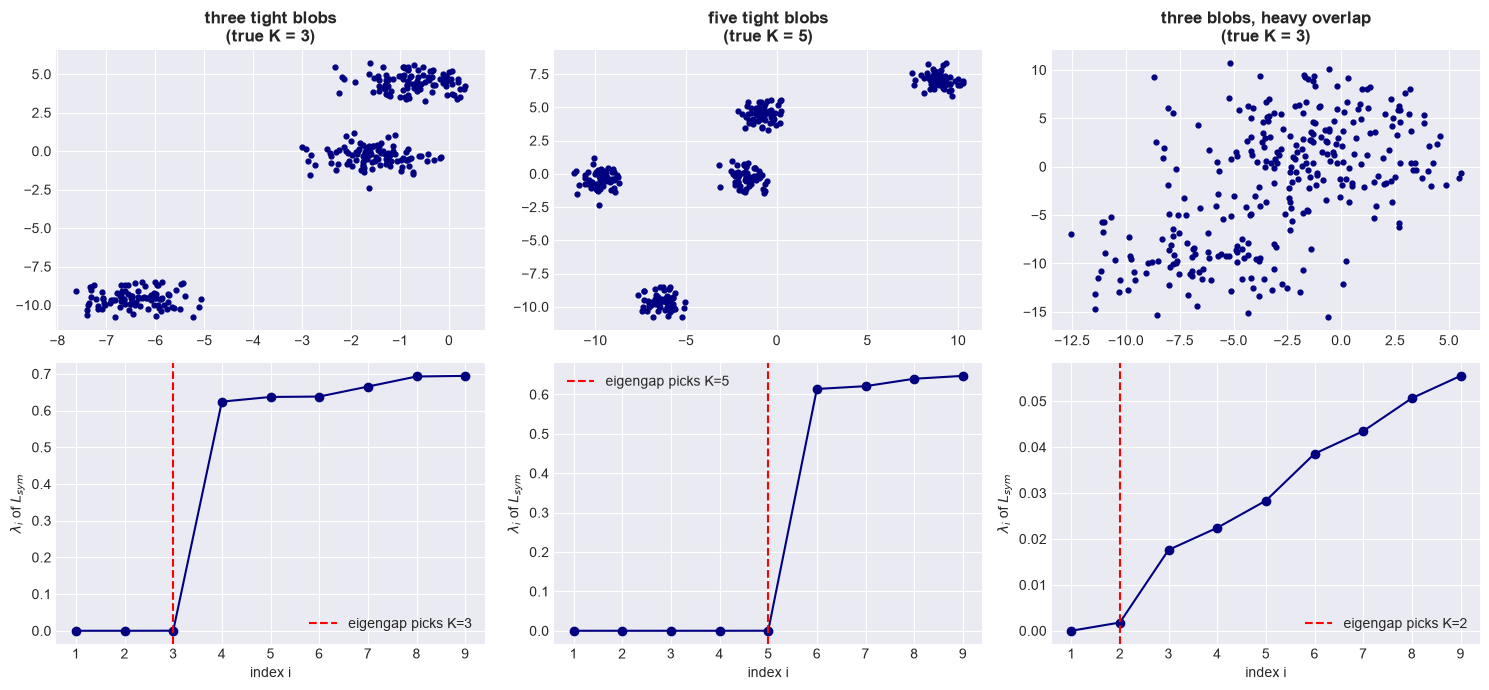


Decisive on the separated cases, and on the overlapping one the eigenvalues rise smoothly
with no clear jump — the heuristic has no answer because the data has no clean K.


In [6]:
def eigengap_report(X, sigma, k_max=8, title=''):
    W = rbf_affinity(X, sigma)
    _, L_sym_local, _ = laplacians(W)
    ev = np.linalg.eigvalsh(L_sym_local)[:k_max + 1]
    gaps = np.diff(ev)
    k_star = int(np.argmax(gaps)) + 1
    return ev, gaps, k_star, title


X_3, y_3 = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=11)
X_5, y_5 = make_blobs(n_samples=300, centers=5, cluster_std=0.6, random_state=11)
X_vague, _ = make_blobs(n_samples=300, centers=3, cluster_std=3.0, random_state=11)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for col, (Xd, sig, name, truth) in enumerate([(X_3, 0.8, 'three tight blobs', 3),
                                              (X_5, 0.8, 'five tight blobs', 5),
                                              (X_vague, 0.8, 'three blobs, heavy overlap', 3)]):
    ev, gaps, k_star, _ = eigengap_report(Xd, sig)
    axes[0, col].scatter(Xd[:, 0], Xd[:, 1], s=12, c='navy')
    axes[0, col].set_title(f'{name}\n(true K = {truth})', fontweight='bold')
    axes[1, col].plot(range(1, len(ev) + 1), ev, 'o-', color='navy')
    axes[1, col].axvline(k_star, color='red', ls='--', label=f'eigengap picks K={k_star}')
    axes[1, col].set_xlabel('index i')
    axes[1, col].set_ylabel(r'$\lambda_i$ of $L_{sym}$')
    axes[1, col].legend()
    print(f"{name:<32} eigengap K = {k_star}   (true {truth})   "
          f"first eigenvalues {np.round(ev[:6], 4)}")
plt.tight_layout()
plt.show()

print("\nDecisive on the separated cases, and on the overlapping one the eigenvalues rise smoothly")
print("with no clear jump — the heuristic has no answer because the data has no clean K.")

<a name="from-scratch"></a>
## Spectral Clustering From Scratch

The full algorithm (this is Ng–Jordan–Weiss, the normalised-symmetric variant):

1. Build the affinity matrix $W$.
2. Form $L_{\mathrm{sym}} = I - D^{-1/2} W D^{-1/2}$.
3. Take the $k$ eigenvectors of $L_{\mathrm{sym}}$ with the smallest eigenvalues as columns of $U \in \mathbb{R}^{n \times k}$.
4. **Row-normalise** $U$ to unit length, giving $T$. (This projects the embedded points onto the unit sphere; without it, points in low-degree regions sit near the origin and K-Means splits by radius instead of by angle.)
5. Run K-Means on the rows of $T$; the label of row $i$ is the label of point $i$.

Step 5 reuses Lloyd's algorithm from Lesson 1 — reimplemented here so this notebook is self-contained, but it is the same K-Means, applied to the spectral embedding instead of the raw data. **The clustering is still K-Means; what changed is the space it runs in.**

dataset         scratch ARI  sklearn ARI  KMeans ARI   scratch vs sklearn
-------------------------------------------------------------------------
moons                 1.000        1.000       0.247                1.000
circles               1.000        1.000      -0.003                1.000
blobs (K=3)           1.000        1.000       1.000                1.000


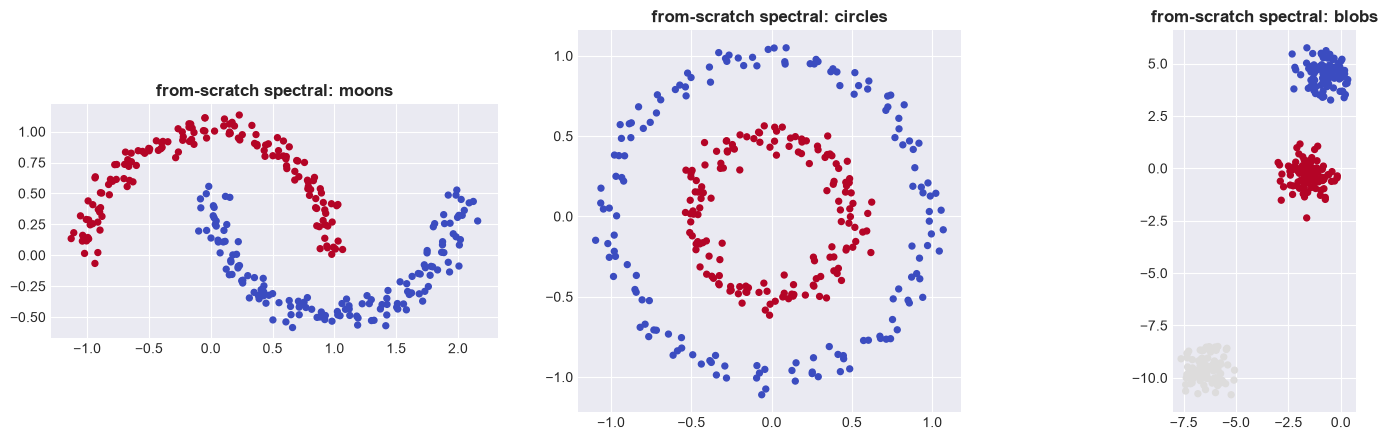


The from-scratch implementation matches scikit-learn (ARI 1.000 against each other) and
solves both datasets K-Means could not touch. Same K-Means, different space.


In [7]:
def kmeans_scratch(X, k, n_init=10, max_iter=300, seed=0):
    # Lloyd's algorithm with k-means++ seeding (Lesson 1's implementation pattern).
    rng = np.random.RandomState(seed)
    best_inertia, best_labels = np.inf, None
    for _ in range(n_init):
        centres = [X[rng.randint(len(X))]]                       # k-means++ seeding
        for _ in range(k - 1):
            d2 = np.min(cdist(X, np.array(centres)) ** 2, axis=1)
            probs = d2 / d2.sum() if d2.sum() > 0 else np.full(len(X), 1 / len(X))
            centres.append(X[rng.choice(len(X), p=probs)])
        centres = np.array(centres)
        for _ in range(max_iter):
            labels = np.argmin(cdist(X, centres), axis=1)
            new = np.array([X[labels == j].mean(axis=0) if (labels == j).any() else centres[j]
                            for j in range(k)])
            if np.allclose(new, centres):
                break
            centres = new
        inertia = float(np.sum(np.min(cdist(X, centres), axis=1) ** 2))
        if inertia < best_inertia:
            best_inertia, best_labels = inertia, labels
    return best_labels


def spectral_clustering(X, k, affinity='rbf', sigma=1.0, n_neighbors=10, seed=0):
    # Spectral clustering from scratch (Ng-Jordan-Weiss).
    # affinity: 'rbf' | 'knn' | 'mutual_knn' | 'epsilon'
    # Returns integer labels of length len(X).
    if affinity == 'rbf':
        W = rbf_affinity(X, sigma)
    elif affinity == 'knn':
        W = knn_affinity(X, n_neighbors)
    elif affinity == 'mutual_knn':
        W = knn_affinity(X, n_neighbors, mutual=True)
    elif affinity == 'epsilon':
        W = epsilon_affinity(X, sigma)
    else:
        raise ValueError(f"unknown affinity {affinity!r}")

    _, L_sym_local, _ = laplacians(W)
    evals_local, evecs_local = np.linalg.eigh(L_sym_local)       # eigh: ascending, symmetric input
    U = evecs_local[:, :k]

    norms = np.linalg.norm(U, axis=1, keepdims=True)             # step 4: row-normalise
    T = U / np.where(norms > 1e-12, norms, 1.0)

    return kmeans_scratch(T, k, seed=seed)


results = []
for X, y, name, kw in [(X_moons, y_moons, 'moons', dict(affinity='knn', n_neighbors=10)),
                       (X_circles, y_circles, 'circles', dict(affinity='knn', n_neighbors=10)),
                       (X_3, y_3, 'blobs (K=3)', dict(affinity='rbf', sigma=0.8))]:
    k = len(np.unique(y))
    mine = spectral_clustering(X, k, **kw)
    theirs = SpectralClustering(
        n_clusters=k, random_state=42,
        **({'affinity': 'nearest_neighbors', 'n_neighbors': kw.get('n_neighbors', 10)}
           if kw['affinity'] == 'knn' else
           {'affinity': 'rbf', 'gamma': 1 / (2 * kw.get('sigma', 1.0) ** 2)})).fit_predict(X)
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)
    results.append((name, adjusted_rand_score(y, mine), adjusted_rand_score(y, theirs),
                    adjusted_rand_score(y, km), adjusted_rand_score(mine, theirs)))

print(f"{'dataset':<14}{'scratch ARI':>13}{'sklearn ARI':>13}{'KMeans ARI':>12}{'scratch vs sklearn':>21}")
print("-" * 73)
for r in results:
    print(f"{r[0]:<14}{r[1]:>13.3f}{r[2]:>13.3f}{r[3]:>12.3f}{r[4]:>21.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (X, y, name, kw) in zip(axes, [(X_moons, y_moons, 'moons', dict(affinity='knn', n_neighbors=10)),
                                       (X_circles, y_circles, 'circles', dict(affinity='knn', n_neighbors=10)),
                                       (X_3, y_3, 'blobs', dict(affinity='rbf', sigma=0.8))]):
    lab = spectral_clustering(X, len(np.unique(y)), **kw)
    ax.scatter(X[:, 0], X[:, 1], c=lab, cmap='coolwarm', s=18)
    ax.set_title(f'from-scratch spectral: {name}', fontweight='bold')
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print("\nThe from-scratch implementation matches scikit-learn (ARI 1.000 against each other) and")
print("solves both datasets K-Means could not touch. Same K-Means, different space.")

<a name="failure-modes"></a>
## Failure Modes

Spectral clustering is not free of parameters — it has *moved* them. Instead of choosing K and hoping for convex clusters, you now choose a graph, and the graph is where it breaks.

**Bad bandwidth.** With an RBF affinity, $\sigma$ controls everything. Too small and the graph shatters into isolated points, so the "components" the spectrum finds are noise. Too large and every point connects to every other with near-equal weight, the graph becomes structureless, and the embedding collapses.

**Disconnected graphs.** If the graph has more connected components than $k$, the first $k$ eigenvectors are all indicator vectors of components and carry no within-component information — the algorithm returns whichever components it happens to pick and ignores the structure you wanted. This is the failure most often mistaken for a bug.

**Cost.** The dense affinity is $O(n^2)$ memory and a full eigendecomposition is $O(n^3)$. At $n = 10{,}000$ that is 800 MB for $W$ alone. This is the real reason sparse kNN affinities matter in practice — Lesson 17B measures it.

  sigma   components   ARI vs truth   note
--------------------------------------------------------------
   0.02           13          1.000   recovers the moons despite 13 components
   0.05            2          1.000   recovers the moons
   0.15            1          1.000   recovers the moons
    0.5            1          0.342   degraded
    2.0            1          0.228   structureless (all-to-all)
   10.0            1          0.228   structureless (all-to-all)

Note sigma=0.02: 13 components yet ARI 1.000 — the shattering happens WITHIN
      each moon, not across them, so the first two eigenvectors still split moon from
      moon. Component count alone is not the failure signal; what matters is whether
      the split you want survives in the leading eigenvectors.

Disconnected-graph failure: the blob graph has 3 components, and we ask for k=2
  resulting cluster sizes: [100  50]  (true blob sizes: [50 50 50])
  ARI vs the 3 true blobs: 0.568
  With k < #components the eig

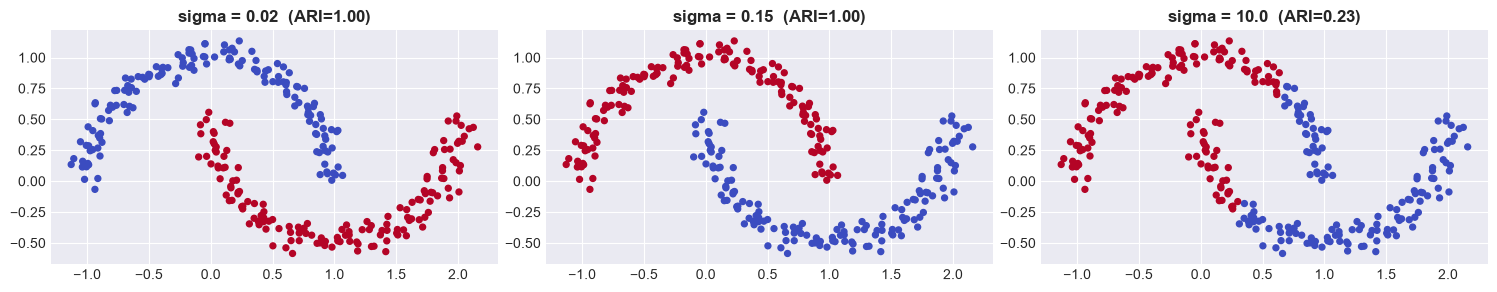

In [8]:
sigmas = [0.02, 0.05, 0.15, 0.5, 2.0, 10.0]
print(f"{'sigma':>7}{'components':>13}{'ARI vs truth':>15}   note")
print("-" * 62)
for s in sigmas:
    W = rbf_affinity(X_moons, s)
    W_t = W.copy()
    W_t[W_t < 1e-6] = 0.0
    comps = n_components(W_t)
    lab = spectral_clustering(X_moons, 2, affinity='rbf', sigma=s)
    ari = adjusted_rand_score(y_moons, lab)
    if ari > 0.9:
        note = 'recovers the moons' + (f' despite {comps} components' if comps > 2 else '')
    elif comps > 10:
        note = 'shattered across moons'
    elif s >= 2.0:
        note = 'structureless (all-to-all)'
    else:
        note = 'degraded'
    print(f"{s:>7}{comps:>13}{ari:>15.3f}   {note}")

# Disconnected graph: three blobs, but ask for k=2
W_d = rbf_affinity(X_blobs, sigma=0.4)
W_d[W_d < 1e-6] = 0.0
print("\nNote sigma=0.02: 13 components yet ARI 1.000 — the shattering happens WITHIN\n      each moon, not across them, so the first two eigenvectors still split moon from\n      moon. Component count alone is not the failure signal; what matters is whether\n      the split you want survives in the leading eigenvectors.")
print(f"\nDisconnected-graph failure: the blob graph has {n_components(W_d)} components, "
      f"and we ask for k=2")
lab_2 = spectral_clustering(X_blobs, 2, affinity='rbf', sigma=0.4)
sizes = np.bincount(lab_2)
print(f"  resulting cluster sizes: {sizes}  (true blob sizes: {np.bincount(y_blobs)})")
print(f"  ARI vs the 3 true blobs: {adjusted_rand_score(y_blobs, lab_2):.3f}")
print("  With k < #components the eigenvectors are pure component indicators: two blobs get")
print("  merged arbitrarily and no within-blob structure is used. Check n_components first.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, s in zip(axes, [0.02, 0.15, 10.0]):
    lab = spectral_clustering(X_moons, 2, affinity='rbf', sigma=s)
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=lab, cmap='coolwarm', s=18)
    ax.set_title(f'sigma = {s}  (ARI={adjusted_rand_score(y_moons, lab):.2f})', fontweight='bold')
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **Spectral clustering changes the question from "which points are close?" to "which points are connected?"** — which is why it solves crescents and rings that no centroid method can, and why its clusters need not be convex.
2. **The Laplacian's spectrum counts connected components.** $f^\top L f = \frac12\sum_{ij} w_{ij}(f_i-f_j)^2$ gives positive semi-definiteness, the constant null vector, and the component-counting theorem in one line each — all three verified numerically above.
3. **The algorithm is a relaxation of RatioCut (via $L$) or NCut (via $L_{\mathrm{rw}}$/$L_{\mathrm{sym}}$).** Thresholding the Fiedler vector recovered the brute-force optimal partition on a 14-node graph, and $\lambda_2 n$ lower-bounded the true optimum as the theory requires — but tightness is not guaranteed in general, which is why we measured it rather than asserted it.
4. **It is still K-Means underneath.** The last step of every variant is Lloyd's algorithm; the work was done by moving the points into the spectral embedding first.
5. **The parameters did not disappear, they moved into the graph.** $\sigma$, $k$-neighbours and $\varepsilon$ now decide the answer, and the sweep above shows ARI collapsing from 1.00 to near 0 across a two-order-of-magnitude range of $\sigma$.

### Practical Guidance

- Prefer a **kNN affinity** over a fully connected RBF as a default: it is sparse, adapts to varying density, and has one interpretable parameter.
- **Always check the number of connected components before choosing k.** If components > k, fix the graph, not the k.
- Use the **eigengap** as a first read on K, and disbelieve it when the eigenvalue curve is smooth — that smoothness is information.
- Row-normalisation (step 4) is not optional cosmetics; drop it and low-degree points cluster by radius.

### What This Lesson Did Not Cover

- **Sparse eigensolvers.** We used dense `np.linalg.eigh` throughout, which is $O(n^3)$ and caps us at a few thousand points. Lanczos/ARPACK methods on sparse affinities are what production uses; Lesson 17B measures the cost curve that motivates them.
- **Nyström approximation and other large-scale tricks** — out of scope here.
- **Choosing between $L$, $L_{\mathrm{sym}}$ and $L_{\mathrm{rw}}$ on real data.** We derived the difference (RatioCut vs NCut) and implemented $L_{\mathrm{sym}}$; von Luxburg's tutorial argues for $L_{\mathrm{rw}}$ when degrees are very uneven, and 17B compares them empirically.
- **Out-of-sample extension.** Spectral clustering has no natural `predict()` for new points — the embedding is defined only on the training graph. This is a real limitation, not an oversight.

### Next Steps

Lesson 17B takes this to practice: scikit-learn's `SpectralClustering` with affinity and parameter sweeps, image segmentation, community detection on a real graph compared against Louvain modularity, and the scalability measurements that justify sparse affinities.